## Features

- [x] one hot encoding
- [x] nucleotid pairs
- [x] promoter strength (understand the one in the article and maybe generate a new one)
- [x] pssm
- [ ] fold energy
- [x] GC content
- [x] have fun

## main model
* Lasso
* XGBoost


## Imports

In [2]:
!pip install biopython

     ---------------------------------------- 2.7/2.7 MB 6.2 MB/s eta 0:00:00


In [3]:
!pip install -r requirements.txt

     --------------------------------------- 70.9/70.9 MB 11.7 MB/s eta 0:00:00
     ---------------------------------------- 9.1/9.1 MB 11.2 MB/s eta 0:00:00
     -------------------------------------- 233.8/233.8 kB 4.8 MB/s eta 0:00:00


In [5]:
import itertools
from Bio import motifs
from Bio.Seq import Seq
from functools import partial
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.metrics import r2_score
from typing import Dict, List, Tuple, Union
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from xgboost import XGBRegressor
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error



## Load Data & Set Constants

In [6]:
# constants
NUCLEOTIDES = 'ACGT' # the order is important in some part of the code (promoter strength)
PROMOTER_LENGTH = 36
START_INDEX = -35
RNAp_EDITED_ZONES = [(-33, -30), (-11, -8)]
RNAi_EDITED_ZONES = [(-33, -30), (-10, -7)]
RNAp_seq_original = 'TTGAGATCCTTTTTTTCTGCGCGTAATCTGCTGCTT'
RNAi_seq_original = 'TTGAAGTGGTGGCCTAACTACGGCTACACTAGAAGA'

# import all suplementary data
RNAp_df = pd.read_excel('https://static-content.springer.com/esm/art%3A10.1038%2Fs41467-022-31422-0/MediaObjects/41467_2022_31422_MOESM5_ESM.xlsx') # priming RNA
timepoints_df = pd.read_excel('https://static-content.springer.com/esm/art%3A10.1038%2Fs41467-022-31422-0/MediaObjects/41467_2022_31422_MOESM6_ESM.xlsx') # priming RNA time points
RNAi_df = pd.read_excel('https://static-content.springer.com/esm/art%3A10.1038%2Fs41467-022-31422-0/MediaObjects/41467_2022_31422_MOESM7_ESM.xlsx') # inhibitory RNA

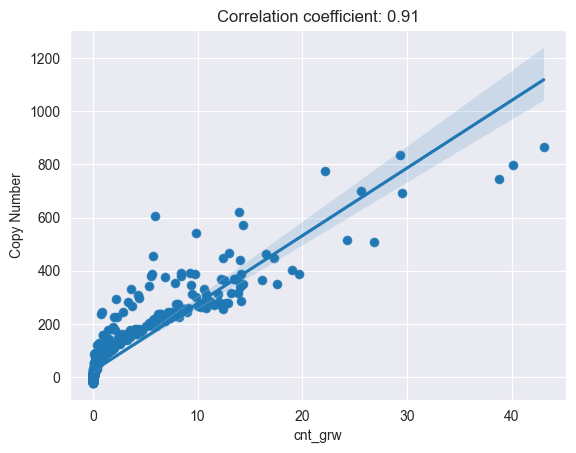

In [8]:
RNAp_df["cnt_grw"] = RNAp_df["Final Counts"] / RNAp_df["Initial Counts"]
corr_coef = RNAp_df['cnt_grw'].corr(RNAp_df['Copy Number'])
sns.scatterplot(x='cnt_grw', y='Copy Number', data=RNAp_df)
plt.title('Correlation coefficient: {:.2f}'.format(corr_coef))
sns.regplot(x='cnt_grw', y='Copy Number', data=RNAp_df)
plt.show()

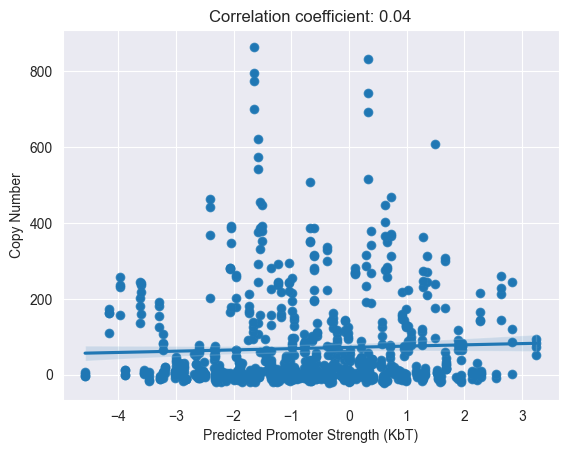

In [9]:
corr_coef = RNAp_df['Predicted Promoter Strength (KbT)'].corr(RNAp_df['Copy Number'])
sns.scatterplot(x='Predicted Promoter Strength (KbT)', y='Copy Number', data=RNAp_df)
plt.title('Correlation coefficient: {:.2f}'.format(corr_coef))
sns.regplot(x='Predicted Promoter Strength (KbT)', y='Copy Number', data=RNAp_df)
plt.show()

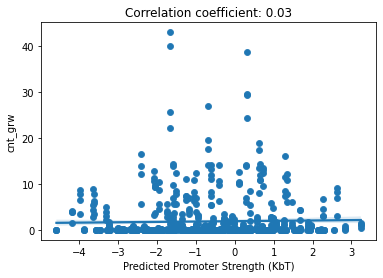

In [13]:
corr_coef = RNAp_df['Predicted Promoter Strength (KbT)'].corr(RNAp_df['cnt_grw'])
sns.scatterplot(x='Predicted Promoter Strength (KbT)', y='cnt_grw', data=RNAp_df)
plt.title('Correlation coefficient: {:.2f}'.format(corr_coef))
sns.regplot(x='Predicted Promoter Strength (KbT)', y='cnt_grw', data=RNAp_df)
plt.show()

const      22.607752
cnt_grw    25.453109
dtype: float64
R-squared: 0.8369287552306315
Mean squared error: 2627.2117994910377


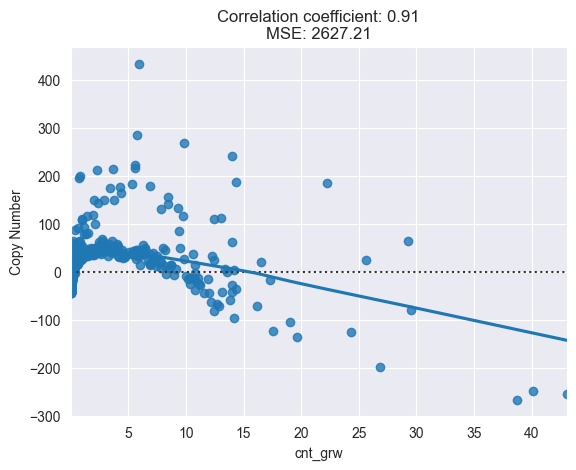

In [10]:
X = RNAp_df["cnt_grw"]
y = RNAp_df["Copy Number"]
X = sm.add_constant(X)
model = sm.OLS(y, X)
results = model.fit()
print(results.params)

# check the model
print('R-squared:', results.rsquared)
mse = np.mean((results.predict(X) - y)**2)
print('Mean squared error:', mse)

# residual plot
sns.residplot(x='cnt_grw', y='Copy Number', data=RNAp_df, lowess=True)
corr_coef = RNAp_df['cnt_grw'].corr(RNAp_df['Copy Number'])
plt.title('Correlation coefficient: {:.2f}\nMSE: {:.2f}'.format(corr_coef, mse))
plt.show()

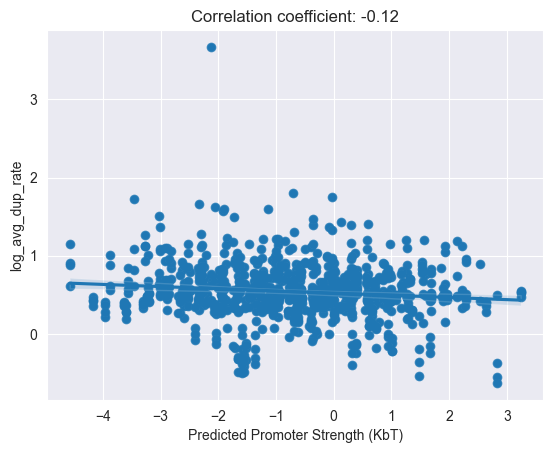

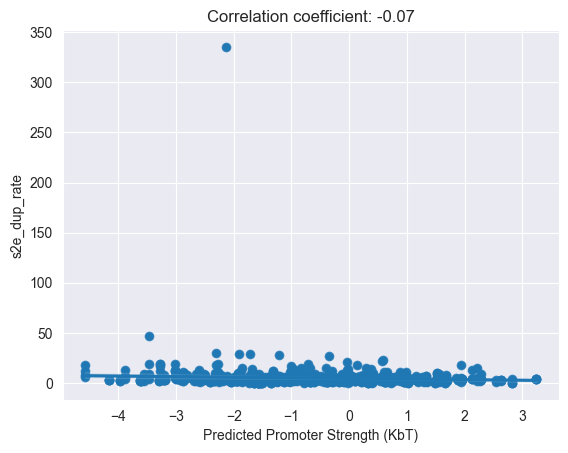

In [11]:
timepoints_df["avg_dup_rate"] = ((timepoints_df["Timepoint 2 Counts"] / timepoints_df["Timepoint 1 Counts"]) + 
                                (timepoints_df["Timepoint 3 Counts"] / timepoints_df["Timepoint 2 Counts"]) + 
                                (timepoints_df["Timepoint 4 Counts"] / timepoints_df["Timepoint 3 Counts"])) / 3

timepoints_df["log_avg_dup_rate"] = np.log(timepoints_df["avg_dup_rate"])
timepoints_df["s2e_dup_rate"] = (timepoints_df["Timepoint 4 Counts"] / timepoints_df["Timepoint 1 Counts"])                                
timepoints_df.rename(columns={"Promoter Sequence (-35 to +1)": "Promoter Sequence"}, inplace=True)
merged = pd.merge(RNAp_df, timepoints_df, on="Promoter Sequence")

corr_coef = merged['log_avg_dup_rate'].corr(RNAp_df['Predicted Promoter Strength (KbT)'])
sns.scatterplot(x='Predicted Promoter Strength (KbT)', y='log_avg_dup_rate', data=merged)
plt.title('Correlation coefficient: {:.2f}'.format(corr_coef))
sns.regplot(x='Predicted Promoter Strength (KbT)', y='log_avg_dup_rate', data=merged)
plt.show()

corr_coef = merged['s2e_dup_rate'].corr(RNAp_df['Predicted Promoter Strength (KbT)'])
sns.scatterplot(x='Predicted Promoter Strength (KbT)', y='s2e_dup_rate', data=merged)
plt.title('Correlation coefficient: {:.2f}'.format(corr_coef))
sns.regplot(x='Predicted Promoter Strength (KbT)', y='s2e_dup_rate', data=merged)
plt.show()

In [26]:
# Extract the independent and dependent variables
X = merged["Predicted Promoter Strength (KbT)"].values.reshape(-1, 1) # independent variable
y = merged["Copy Number"].values.reshape(-1, 1) # dependent variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Set the degrees of the polynomial
degrees = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# Initialize variables for the best model
best_degree = None
best_mse = float('inf')
best_model = None

# Loop through each degree and fit a polynomial regression model
for degree in degrees:
    # Create polynomial features
    poly_features = PolynomialFeatures(degree=degree)
    X_train_poly = poly_features.fit_transform(X_train)
    # Fit the model
    poly_reg = LinearRegression()
    poly_reg.fit(X_train_poly, y_train)

    # Predict the values
    X_test_poly = poly_features.transform(X_test)
    y_pred = poly_reg.predict(X_test_poly)

    # Calculate the mean squared error
    mse = mean_squared_error(y_test, y_pred)

    # Check if this model is the best so far
    if mse < best_mse:
        best_mse = mse
        best_degree = degree
        best_model = poly_reg

# Print the best degree and model
print("Best degree: ", best_degree)
print("MSE: ", best_mse)

C:\Program Files\JetBrains\PyCharm 2022.2.3\plugins\python\helpers\pydev\_pydevd_bundle\pydevd_utils.py:606: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  for item in s.iteritems():
C:\Program Files\JetBrains\PyCharm 2022.2.3\plugins\python\helpers\pydev\_pydevd_bundle\pydevd_utils.py:606: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  for item in s.iteritems():
C:\Program Files\JetBrains\PyCharm 2022.2.3\plugins\python\helpers\pydev\_pydevd_bundle\pydevd_utils.py:606: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  for item in s.iteritems():
C:\Program Files\JetBrains\PyCharm 2022.2.3\plugins\python\helpers\pydev\_pydevd_bundle\pydevd_utils.py:606: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  for item in s.iteritems():
C:\Program Files\JetBrains\PyCharm 2022.2.3\plug

Best degree:  12
MSE:  17940.604199797315


## PSSM

### RNAp

In [38]:
copynumber_threshold = RNAp_df["Copy Number"].mean()
print(f'RNAp average copy number: {copynumber_threshold}')

RNAp_lowcopy = RNAp_df[RNAp_df["Copy Number"] <= copynumber_threshold]
RNAp_highcopy = RNAp_df[RNAp_df["Copy Number"] > copynumber_threshold]
print(f'high copy: {len(RNAp_highcopy)}, low copy: {len(RNAp_lowcopy)}')


RNAp average copy number: 69.5473025210084
high copy: 239, low copy: 594
[[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1

In [39]:
lowcopy_promoter_seqs = []
for index, row in RNAp_lowcopy.iterrows():
  lowcopy_promoter_seqs.append(row["Promoter Sequence"])

lowcopy_motifs=motifs.create(lowcopy_promoter_seqs)
print(lowcopy_motifs.counts)

        0      1      2      3      4      5      6      7      8      9     10     11     12     13     14     15     16     17     18     19     20     21     22     23     24     25     26     27     28     29     30     31     32     33     34     35
A:   0.00   0.00   0.00 280.00 252.00 274.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00 290.00 296.00 314.00 331.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00 128.00
C:   0.00   0.00   0.00 314.00 341.00 320.00   0.00 594.00 594.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00 594.00   0.00   0.00 594.00   0.00 594.00   0.00   0.00   0.00   0.00   0.00 263.00   0.00   0.00 594.00   0.00   0.00 594.00   0.00 122.00
G:   0.00   0.00 345.00   0.00   1.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00 594.00   0.00 594.00   0.00 594.00   0.00   0.00   0.00 279.00   0.00   0.00 594.00   0.00   0.00 594.00  

In [15]:
lowcopy_motifs.weblogo("RNAp_lowcopy_motifs.png", first_index = START_INDEX)

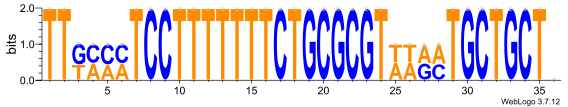

In [ ]:
highcopy_promoter_seqs = []
for index, row in RNAp_highcopy.iterrows():
  highcopy_promoter_seqs.append(row["Promoter Sequence"])

highcopy_motifs=motifs.create(highcopy_promoter_seqs)
print(highcopy_motifs.counts)

        0      1      2      3      4      5      6      7      8      9     10     11     12     13     14     15     16     17     18     19     20     21     22     23     24     25     26     27     28     29     30     31     32     33     34     35
A:   0.00   0.00   0.00 119.00 135.00 122.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00 168.00 142.00 122.00 132.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00  66.00
C:   0.00   0.00   0.00 120.00 104.00 117.00   0.00 239.00 239.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00 239.00   0.00   0.00 239.00   0.00 239.00   0.00   0.00   0.00   0.00   0.00 107.00   0.00   0.00 239.00   0.00   0.00 239.00   0.00  56.00
G:   0.00   0.00  83.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00 239.00   0.00 239.00   0.00 239.00   0.00   0.00   0.00 117.00   0.00   0.00 239.00   0.00   0.00 239.00  

In [ ]:
highcopy_motifs.weblogo("RNAp_highcopy_motifs.png", first_index = START_INDEX)

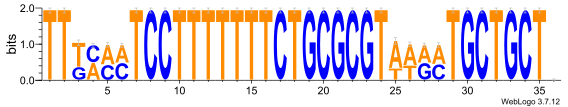

### Model

In [ ]:
pd.DataFrame(highcopy_motifs.counts)

,A,C,G,T
0,0,0,0,153
1,0,0,0,153
2,0,0,52,101
3,82,71,0,0
4,97,56,0,0
5,108,44,1,0
6,0,0,0,153
7,0,0,153,0
8,0,0,153,0
9,0,0,0,153


In [24]:
X_train, X_test, y_train, y_test = train_test_split(highcopy_motifs)
# RNA p
xgb_model_p = XGBRegressor()
xgb_model_p.fit(X_train_p, y_train_p) 
y_pred_p = xgb_model_p.predict(X_test_p)
# RNA i
xgb_model_i = XGBRegressor()
xgb_model_i.fit(X_train_i, y_train_i)
y_pred_i = xgb_model_i.predict(X_test_i)

NameError: name 'highcopy_motifs' is not defined

### RNAi

In [ ]:
copynumber_threshold = RNAi_df["Copy Number"].mean()
print(f'RNAi average copy number: {copynumber_threshold}')

RNAi_lowcopy = RNAi_df[RNAi_df["Copy Number"] <= copynumber_threshold]
RNAi_highcopy = RNAi_df[RNAi_df["Copy Number"] > copynumber_threshold]
print(f'high copy: {len(RNAi_highcopy)}, low copy: {len(RNAi_lowcopy)}')

RNAi average copy number: 99.37191832810866
high copy: 153, low copy: 213


In [ ]:
lowcopy_promoter_seqs = []
for index, row in RNAi_lowcopy.iterrows():
  lowcopy_promoter_seqs.append(row["Promoter Sequence (-35 to +1)"])

lowcopy_motifs=motifs.create(lowcopy_promoter_seqs)
print(lowcopy_motifs.counts)

        0      1      2      3      4      5      6      7      8      9     10     11     12     13     14     15     16     17     18     19     20     21     22     23     24     25     26     27     28     29     30     31     32     33     34     35
A:   0.00   0.00   0.00 139.00 125.00 135.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00 213.00 213.00   0.00   0.00 213.00   0.00   0.00   0.00   0.00   0.00  87.00  74.00 196.00 129.00   0.00 213.00   0.00 213.00 213.00   0.00  46.00
C:   0.00   0.00   0.00  74.00  88.00  78.00   0.00   0.00   0.00   0.00   0.00   0.00 213.00 213.00   0.00   0.00   0.00 213.00   0.00   0.00 213.00   0.00   0.00 213.00   0.00   0.00   0.00   0.00  84.00   0.00   0.00   0.00   0.00   0.00   0.00  43.00
G:   0.00   0.00  94.00   0.00   0.00   0.00   0.00 213.00 213.00   0.00 213.00 213.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00 213.00 213.00   0.00   0.00   0.00   0.00  17.00   0.00   0.00   0.00 213.00   0.00  

In [ ]:
lowcopy_motifs.weblogo("RNAi_lowcopy_motifs.png")

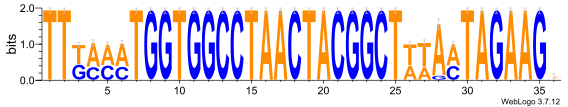

In [ ]:
highcopy_promoter_seqs = []
for index, row in RNAi_highcopy.iterrows():
  highcopy_promoter_seqs.append(row["Promoter Sequence (-35 to +1)"])

highcopy_motifs=motifs.create(highcopy_promoter_seqs)
print(highcopy_motifs.counts)

        0      1      2      3      4      5      6      7      8      9     10     11     12     13     14     15     16     17     18     19     20     21     22     23     24     25     26     27     28     29     30     31     32     33     34     35
A:   0.00   0.00   0.00  82.00  97.00 108.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00 153.00 153.00   0.00   0.00 153.00   0.00   0.00   0.00   0.00   0.00 114.00  76.00 124.00 105.00   0.00 153.00   0.00 153.00 153.00   0.00  37.00
C:   0.00   0.00   0.00  71.00  56.00  44.00   0.00   0.00   0.00   0.00   0.00   0.00 153.00 153.00   0.00   0.00   0.00 153.00   0.00   0.00 153.00   0.00   0.00 153.00   0.00   0.00   1.00   0.00  48.00   0.00   0.00   0.00   0.00   0.00   0.00  31.00
G:   0.00   0.00  52.00   0.00   0.00   1.00   0.00 153.00 153.00   0.00 153.00 153.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00 153.00 153.00   0.00   0.00   0.00   0.00  29.00   0.00   0.00   0.00 153.00   0.00  

In [ ]:
highcopy_motifs.weblogo("RNAi_highcopy_motifs.png")

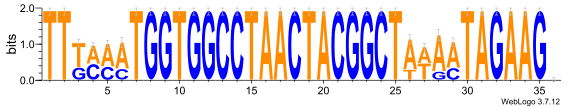

## Features Extraction Functions

In [16]:
def generate_one_hot_encoding(seq: pd.Series) -> pd.DataFrame:
  def encode(single_nucleotid: pd.Series, index:int=None) -> pd.DataFrame:
    columns = []
    for nucleotide in NUCLEOTIDES:
      columns.append((single_nucleotid == nucleotide).astype(int))
    encoded = pd.concat(columns, axis=1)
    if index is not None:
      columns = [f'{nucleotide}_{index}' for nucleotide in NUCLEOTIDES]
    else:
      columns = list(NUCLEOTIDES)
    encoded.columns = columns
    return encoded

  full_encoding = []
  for current_nucleotide_index in range(PROMOTER_LENGTH):
    current_nucleotide_encoding = encode(seq.str[current_nucleotide_index], current_nucleotide_index + START_INDEX)
    full_encoding.append(current_nucleotide_encoding)

  return pd.concat(full_encoding, axis=1)

Use extract to get 5947 features in dict for each sequence

In [17]:
m2 = list(itertools.product(NUCLEOTIDES, repeat=2))
m3 = list(itertools.product(NUCLEOTIDES, repeat=3))
m4 = list(itertools.product(NUCLEOTIDES, repeat=4))
m5 = list(itertools.product(NUCLEOTIDES, repeat=5))
k_gap = 2
k_tuple=2

def kmers(seq: str, k: int) -> List[int]:
    v = []
    for i in range(len(seq) - k + 1):
        v.append(seq[i:i + k])
    return v

def pseudo_knc(seq: str, k: int) -> Dict[str, int]:
    ### k-mer ###
    ### A, AA, AAA

    d = {}
    for i in range(1, k + 1):
        v = list(itertools.product(NUCLEOTIDES, repeat=i))
        for j in v:
            search_seq = ''.join(j)
            key = f'{search_seq}_count'
            res = seq.count(search_seq)
            d.update({key: res})
    return d

def z_curve(seq: str) -> Dict[str, int]:
    ### Z-Curve ### total = 3

        T = seq.count('T')
        A = seq.count('A')
        C = seq.count('C')
        G = seq.count('G')

        x_ = (A + G) - (C + T)
        y_ = (A + C) - (G + T)
        z_ = (A + T) - (C + G)

        d = {'z_curve_x_': x_, 'z_curve_y_': y_, 'z_curve_z_': z_}
        return d
       

def gc_content(seq: str) -> Dict[str, float]:
    T = seq.count('T')
    A = seq.count('A')
    C = seq.count('C')
    G = seq.count('G')

    gc_content = (G + C) / (A + C + G + T)
    return {'gc_content': gc_content}

def cumulative_skew(seq: str) -> Dict[str, float]:
    T = seq.count('T')
    A = seq.count('A')
    C = seq.count('C')
    G = seq.count('G')

    GCSkew = (G - C) / (G + C)
    ATSkew = (A - T) / (A + T)

    d = {'gc_skew': GCSkew, 'at_skew': ATSkew}
    return d

def atgc_ratio(seq: str) -> Dict[str, float]:
        T = seq.count('T')
        A = seq.count('A')
        C = seq.count('C')
        G = seq.count('G')

        atgc_ratio = (A + T) / (G + C)
        return {'atgc_ratio': atgc_ratio}

def mono_mono_k_gap(seq: str, g: int) -> Dict[str, int]:  # 1___1
    ### g-gap
    '''
    AA      0-gap (2-mer)
    A_A     1-gap
    A__A    2-gap
    A___A   3-gap
    A____A  4-gap
    '''

    d = {}
    m = m2
    for i in range(1, g + 1, 1):
        V = kmers(seq, i + 2)
        
        for gGap in m:
            C = 0
            for v in V:
                if v[0] == gGap[0] and v[-1] == gGap[1]:
                    C += 1
            key = f'mono_mono_k_gap_{i}_{gGap}_'
            d[key] = C

    return d

def mono_di_k_gap(seq: str, g: int) -> Dict[str, int]:  # 1___2

    d = {}
    m = m3
    for i in range(1, g + 1, 1):
        V = kmers(seq, i + 3)
        for gGap in m:
            
            C = 0
            for v in V:
                if v[0] == gGap[0] and v[-2] == gGap[1] and v[-1] == gGap[2]:
                    C += 1

            key = f'mono_di_k_gap_{i}_{gGap}_'
            d[key] = C

    return d

def di_mono_k_gap(seq: str, g: int) -> Dict[str, int]:  # 2___1

    d = {}
    m = m3
    for i in range(1, g + 1, 1):
        V = kmers(seq, i + 3)
        
        for gGap in m:
            C = 0
            for v in V:
                if v[0] == gGap[0] and v[1] == gGap[1] and v[-1] == gGap[2]:
                    C += 1
            key = f'di_mono_k_gap_{i}_{gGap}_'
            d.update({key: C})

    return d

def mono_tri_k_gap(seq: str, g: int) -> Dict[str, int]:  # 1___3

    # A_AAA       1-gap
    # A__AAA      2-gap
    # A___AAA     3-gap
    # A____AAA    4-gap
    # A_____AAA   5-gap upto g

    d = {}
    m = m4
    for i in range(1, g + 1, 1):
        V = kmers(seq, i + 4)
        
        for gGap in m:
            C = 0
            for v in V:
                if v[0] == gGap[0] and v[-3] == gGap[1] and v[-2] == gGap[2] and v[-1] == gGap[3]:
                    C += 1
            key = f'mono_tri_k_gap_{i}_{gGap}_'
            d[key] = C

    return d

def tri_mono_k_gap(seq: str, g: int) -> Dict[str, int]:  # 3___1

    # AAA_A       1-gap
    # AAA__A      2-gap
    # AAA___A     3-gap
    # AAA____A    4-gap
    # AAA_____A   5-gap upto g

    d = {}
    m = m4
    for i in range(1, g + 1, 1):
        V = kmers(seq, i + 4)
       
        for gGap in m:
            C = 0
            for v in V:
                if v[0] == gGap[0] and v[1] == gGap[1] and v[2] == gGap[2] and v[-1] == gGap[3]:
                    C += 1
            
            key = f'tri_mono_k_gap_{i}_{gGap}_'
            d[key] = C

    return d

def di_di_k_gap(seq: str, g: int) -> Dict[str, int]:

    ### gapping ### total = [(64xg)] = 2,304 [g=9]
    # AA_AA       1-gap
    # AA__AA      2-gap
    # AA___AA     3-gap
    # AA____AA    4-gap
    # AA_____AA   5-gap upto g

    d = {}
    m = m4
    for i in range(1, g + 1, 1):
        V = kmers(seq, i + 4)
       
        for gGap in m:
            C = 0
            for v in V:
                if v[0] == gGap[0] and v[1] == gGap[1] and v[-2] == gGap[2] and v[-1] == gGap[3]:
                    C += 1
            key = f'di_di_k_gap_{i}_{gGap}_'
            d[key] = C

    return d

def di_tri_k_gap(seq: str, g: int) -> Dict[str, int]:  # 2___3

    ### gapping ### total = [(64xg)] = 2,304 [g=9]
    # AA_AAA       1-gap
    # AA__AAA      2-gap
    # AA___AAA     3-gap
    # AA____AAA    4-gap
    # AA_____AAA   5-gap upto g

    d = {}
    m = m5
    for i in range(1, g + 1, 1):
        V = kmers(seq, i + 5)
        for gGap in m:
            C = 0
            for v in V:
                if v[0] == gGap[0] and v[1] == gGap[1] and v[-3] == gGap[2] and \
                        v[-2] == gGap[3] and v[-1] == gGap[4]:
                    C += 1
            key = f'di_tri_k_gap_{i}_{gGap}_'
            d[key] = C

    return d

def tri_di_k_gap(seq: str, g):  # 3___2

    ### gapping ### total = [(64xg)] = 2,304 [g=9]
    # AAA_AA       1-gap
    # AAA__AA      2-gap
    # AAA___AA     3-gap
    # AAA____AA    4-gap
    # AAA_____AA   5-gap upto g

    d = {}
    m = m5
    for i in range(1, g + 1, 1):
        V = kmers(seq, i + 5)
        for gGap in m:
            C = 0
            for v in V:
                if v[0] == gGap[0] and v[1] == gGap[1] and v[2] == gGap[2] and \
                        v[-2] == gGap[3] and v[-1] == gGap[4]:
                    C += 1
            key = f'tri_di_k_gap_{i}_{gGap}_'
            d[key] = C

    return d

def extract(seq: str) -> Dict[str, Union[int, float]]:
    d = {}

    res = z_curve(seq)  
    d.update(res)

    res = gc_content(seq)  
    d.update(res)

    res = cumulative_skew(seq) 
    d.update(res)

    res = atgc_ratio(seq)  
    d.update(res)

    res = pseudo_knc(seq, k_tuple)  # k=2|(16), k=3|(64), k=4|(256), k=5|(1024)
    d.update(res)

    res = mono_mono_k_gap(seq, k_gap)  # 4*(k)*4 = 240
    d.update(res)

    res = mono_di_k_gap(seq, k_gap)  # 4*k*(4^2) = 960
    d.update(res)

    res = mono_tri_k_gap(seq, k_gap)  # 4*k*(4^3) = 3,840
    d.update(res)
    
    res = di_mono_k_gap(seq, k_gap)  # (4^2)*k*(4)    = 960
    d.update(res)

    res = di_di_k_gap(seq, k_gap)  # (4^2)*k*(4^2)  = 3,840
    d.update(res)

    res = di_tri_k_gap(seq, k_gap)  # (4^2)*k*(4^3)  = 15,360
    d.update(res)

    res = tri_mono_k_gap(seq, k_gap)  # (4^3)*k*(4)    = 3,840
    d.update(res)

    res = tri_di_k_gap(seq, k_gap)  # (4^3)*k*(4^2)  = 15,360
    d.update(res)

    return d

In [18]:
def generate_df_from_seq(seq: 'pd.Series[str]') -> pd.DataFrame:
  return pd.DataFrame(seq.apply(extract).tolist())

In [19]:
def get_energy_matrix_for_rna_polymeras() -> pd.DataFrame:
  '''
    from https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1002811
    data link: https://doi.org/10.1371/journal.pcbi.1002811.s003
    Energy matrix for RNAP in kT. Inferred from an experiment done in
    TK310 with no supplemental cAMP (and hence, no CRP present in the
    cells). The matrix covers base pairs [-41:-1] where 0 denotes the
    transcription start site. Each row corresponds to a given position;
    each column corresponds to a value for that base pair. The columns
    are ordered [A,C,G,T].
  '''
  FIRST_INDEX = -40
  RAW_DATA = np.loadtxt('https://doi.org/10.1371/journal.pcbi.1002811.s003')
  return pd.DataFrame(RAW_DATA, columns=list(NUCLEOTIDES), index=np.arange(FIRST_INDEX, FIRST_INDEX + len(RAW_DATA)))

  sns.heatmap(RAW_DATA.T, cmap='jet', square=True, yticklabels = ['A','C','G','T'])

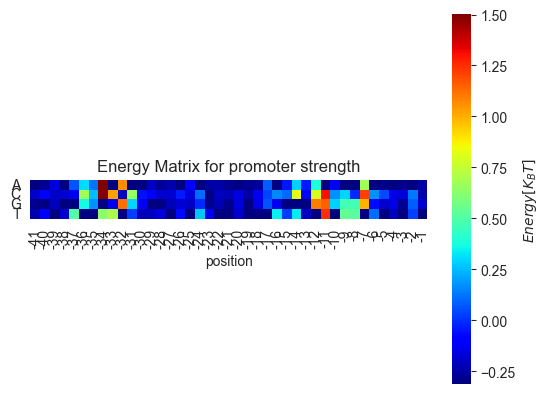

In [20]:
# plot the energy matrix
RAW_DATA = np.loadtxt('https://doi.org/10.1371/journal.pcbi.1002811.s003').transpose()

fig = sns.heatmap(RAW_DATA, cmap='jet', square=True, yticklabels = ['A','C','G','T'], xticklabels = range(-41,0), cbar_kws={'label': r'$Energy [K_{B}T]$'})
_ = fig.set_title('Energy Matrix for promoter strength')
_ = fig.set_xlabel('position')

In [21]:
def calc_promoter_zones_strength(seq: 'pd.Series[str]', zones=List[Tuple[int]]) -> pd.DataFrame:
  energy_matrix = get_energy_matrix_for_rna_polymeras()

  def calc_zone_strength(seq:str, zone: Tuple[int], energy_matrix) -> 'pd.Series[float]':
    seq = seq[:-1] # delete +1 position
    start_zone, end_zone = zone
    strength = 0

    for i in range(start_zone, end_zone + 1):
      strength += energy_matrix.loc[i, seq[i - START_INDEX]]
    return strength

  zones_strength = {}
  for zone in zones:
    strength = seq.apply(
        partial(calc_zone_strength, zone=zone, energy_matrix=energy_matrix)
        )
    zones_strength[f'{zone} predicted strength'] = strength

  return pd.DataFrame(zones_strength)

# calc_promoter_zones_strength(RNAi_df['Promoter Sequence (-35 to +1)'], RNAi_EDITED_ZONES)

## Concat All Features into One df

In [58]:
def remove_zero_variance_features(X: pd.DataFrame) -> pd.DataFrame:
  zero_variance_cols = X.columns[X.var() == 0]
  return X.drop(zero_variance_cols, axis=1)

In [53]:
def create_hight_or_low_features(X: pd.DataFrame,Type_of_thresh) -> pd.DataFrame:
    l=['mean','median']
    if Type_of_thresh not in l:
        while True:
            u_in = input("Please enter a precentage between 0 and 100: ")
            try:
                number = float(u_in)
                if 0 <= number <= 100:
                    Threshold=max(X["Copy Number"])*number/100
                    break
                else:
                    print("The number must be between 0 and 100.")
            except ValueError:
                print("Invalid input. Please enter a valid number.")
    elif Type_of_thresh=='mean':
        Threshold = X["Copy Number"].mean()
    elif Type_of_thresh=='med':
        Threshold = X["Copy Number"].median()

    return(pd.DataFrame(np.array([X["Copy Number"] <= Threshold]).T.astype(int),columns=['Hight_or_low']))




### RNAp

In [65]:
RNAp_seq = RNAp_df['Promoter Sequence']
RNAp_features = []
RNAp_features.append(RNAp_df['Predicted Promoter Strength (KbT)'])
RNAp_features.append(generate_one_hot_encoding(RNAp_seq))
RNAp_features.append(generate_df_from_seq(RNAp_seq))
RNAp_features.append(calc_promoter_zones_strength(RNAp_seq, RNAp_EDITED_ZONES))
RNAp_features.append(create_hight_or_low_features(RNAp_df,Type_of_thresh='mean')) # except "mean", "med",and %

RNAp_X = remove_zero_variance_features(pd.DataFrame(pd.concat(RNAp_features, axis=1)))
RNAp_y = RNAp_df['Copy Number']
RNAp_X.head()

,Predicted Promoter Strength (KbT),G_-33,T_-33,A_-32,C_-32,A_-31,C_-31,G_-31,A_-30,C_-30,...,"tri_di_k_gap_2_('T', 'T', 'C', 'T', 'C')_","tri_di_k_gap_2_('T', 'T', 'G', 'A', 'T')_","tri_di_k_gap_2_('T', 'T', 'G', 'C', 'T')_","tri_di_k_gap_2_('T', 'T', 'G', 'G', 'C')_","tri_di_k_gap_2_('T', 'T', 'T', 'A', 'T')_","tri_di_k_gap_2_('T', 'T', 'T', 'C', 'T')_","tri_di_k_gap_2_('T', 'T', 'T', 'T', 'G')_","(-33, -30) predicted strength","(-11, -8) predicted strength",Hight_or_low
0,0.602,1,0,0,1,0,1,0,0,1,...,0,0,1,0,0,1,1,1.160192,1.798910,1
1,-0.355,1,0,1,0,1,0,0,0,1,...,0,0,1,1,0,1,2,1.093200,0.908485,1
2,-0.297,0,1,0,1,0,1,0,0,1,...,1,0,0,0,0,2,1,2.107489,-0.048115,1
3,1.938,0,1,0,1,1,0,0,0,1,...,1,0,0,1,0,2,2,3.386169,0.908485,1
4,0.294,0,1,0,1,0,1,0,1,0,...,1,0,0,1,1,1,2,1.138648,1.512424,1


### RNAi

In [67]:
RNAi_seq = RNAi_df['Promoter Sequence (-35 to +1)']
RNAi_features = []
RNAi_features.append(RNAi_df['Predicted Promoter Strength'])
RNAi_features.append(generate_one_hot_encoding(RNAi_seq))
RNAi_features.append(generate_df_from_seq(RNAi_seq))
RNAi_features.append(calc_promoter_zones_strength(RNAi_seq, RNAi_EDITED_ZONES))
RNAi_features.append(create_hight_or_low_features(RNAi_df,Type_of_thresh='mean')) # except "mean", "med",and %

RNAi_X = remove_zero_variance_features(pd.concat(RNAi_features, axis=1))

RNAi_y = RNAi_df['Copy Number']
RNAi_X.head()

,Predicted Promoter Strength,G_-33,T_-33,A_-32,C_-32,A_-31,C_-31,A_-30,C_-30,G_-30,...,"tri_di_k_gap_2_('T', 'T', 'G', 'A', 'G')_","tri_di_k_gap_2_('T', 'T', 'G', 'A', 'T')_","tri_di_k_gap_2_('T', 'T', 'G', 'C', 'T')_","tri_di_k_gap_2_('T', 'T', 'G', 'G', 'T')_","tri_di_k_gap_2_('T', 'T', 'T', 'A', 'T')_","tri_di_k_gap_2_('T', 'T', 'T', 'C', 'T')_","tri_di_k_gap_2_('T', 'T', 'T', 'T', 'A')_","(-33, -30) predicted strength","(-10, -7) predicted strength",Hight_or_low
0,-2.949987,1,0,0,1,1,0,0,1,0,...,0,0,1,0,0,0,1,2.438873,0.608106,1
1,-8.404997,1,0,1,0,0,1,1,0,0,...,0,1,0,0,0,0,0,-1.154321,-1.253709,1
2,-4.627045,0,1,1,0,0,1,0,1,0,...,0,0,0,0,0,1,1,0.761815,0.608106,1
3,-4.811803,1,0,0,1,1,0,0,1,0,...,0,0,1,0,0,0,0,2.438873,-1.253709,1
4,-3.582648,0,1,0,1,0,1,0,1,0,...,0,0,0,0,0,1,1,2.107489,0.306830,1


### RNAp & RNAi combined

In [ ]:
combined_X = remove_zero_variance_features(pd.concat([
    pd.concat(RNAp_features, axis=1),
    pd.concat(RNAi_features, axis=1),
], axis=0, ignore_index=True))
combined_y = pd.concat([RNAp_y, RNAi_y], axis=0, ignore_index=True)

combined_X.head()

Original promoters features

In [59]:
RNAi_seq_original = pd.Series(RNAi_seq_original)
RNAi_original_features = []
RNAi_original_features.append(generate_one_hot_encoding(RNAi_seq_original))
RNAi_original_features.append(generate_df_from_seq(RNAi_seq_original))
RNAi_original_features.append(calc_promoter_zones_strength(RNAi_seq_original, [(-35,-1)]))
RNAi_original_features = pd.concat(RNAi_original_features, axis=1)
RNAi_original_features = pd.DataFrame(np.repeat(RNAi_original_features.values, RNAp_X.shape[0], axis=0), columns=RNAi_original_features.columns)

RNAp_X_shared_model = pd.concat([RNAp_X, RNAi_original_features], axis = 1)

NameError: name 'RNAp_X' is not defined

In [ ]:
RNAp_X_shared_model

In [ ]:
RNAp_seq_original = pd.Series(RNAp_seq_original)
RNAp_original_features = []
RNAp_original_features.append(generate_one_hot_encoding(RNAp_seq_original))
RNAp_original_features.append(generate_df_from_seq(RNAp_seq_original))
RNAp_original_features.append(calc_promoter_zones_strength(RNAp_seq_original, [(-35,-1)]))
RNAp_original_features = pd.concat(RNAp_original_features, axis=1)
RNAp_original_features = pd.DataFrame(np.repeat(RNAp_original_features.values, RNAi_X.shape[0], axis=0), columns=RNAp_original_features.columns)

RNAi_X_shared_model = pd.concat([RNAi_X, RNAp_original_features], axis = 1)

In [ ]:
RNAi_X_shared_model

,Predicted Promoter Strength,A_-35,C_-35,G_-35,T_-35,A_-34,C_-34,G_-34,T_-34,A_-33,...,"tri_di_k_gap_2_('T', 'T', 'T', 'C', 'T')_","tri_di_k_gap_2_('T', 'T', 'T', 'G', 'A')_","tri_di_k_gap_2_('T', 'T', 'T', 'G', 'C')_","tri_di_k_gap_2_('T', 'T', 'T', 'G', 'G')_","tri_di_k_gap_2_('T', 'T', 'T', 'G', 'T')_","tri_di_k_gap_2_('T', 'T', 'T', 'T', 'A')_","tri_di_k_gap_2_('T', 'T', 'T', 'T', 'C')_","tri_di_k_gap_2_('T', 'T', 'T', 'T', 'G')_","tri_di_k_gap_2_('T', 'T', 'T', 'T', 'T')_","(-35, -1) predicted strength"
0,-2.949987,0,0,0,1,0,0,0,1,0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,-2.129405
1,-8.404997,0,0,0,1,0,0,0,1,0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,-2.129405
2,-4.627045,0,0,0,1,0,0,0,1,0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,-2.129405
3,-4.811803,0,0,0,1,0,0,0,1,0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,-2.129405
4,-3.582648,0,0,0,1,0,0,0,1,0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,-2.129405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,-5.988566,0,0,0,1,0,0,0,1,0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,-2.129405
362,-4.320071,0,0,0,1,0,0,0,1,0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,-2.129405
363,-5.396467,0,0,0,1,0,0,0,1,0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,-2.129405
364,-5.733616,0,0,0,1,0,0,0,1,0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,-2.129405


In [40]:
RNAi_X_shared_model.reset_index(inplace=True, drop=True)
RNAp_X_shared_model.reset_index(inplace=True, drop=True)
RNAi_X_shared_model.columns = range(RNAi_X_shared_model.shape[1])
RNAp_X_shared_model.columns = range(RNAp_X_shared_model.shape[1])
X_shared_model = pd.concat([RNAi_X_shared_model, RNAp_X_shared_model], axis = 0, ignore_index=True)
Y_shared_model = pd.concat([RNAi_y, RNAp_y], axis = 0, ignore_index=True)

NameError: name 'RNAi_X_shared_model' is not defined

In [ ]:
X_shared_model

,0,1,2,3,4,5,6,7,8,9,...,12176,12177,12178,12179,12180,12181,12182,12183,12184,12185
0,-2.949987,0,0,0,1,0,0,0,1,0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,-2.129405
1,-8.404997,0,0,0,1,0,0,0,1,0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,-2.129405
2,-4.627045,0,0,0,1,0,0,0,1,0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,-2.129405
3,-4.811803,0,0,0,1,0,0,0,1,0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,-2.129405
4,-3.582648,0,0,0,1,0,0,0,1,0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,-2.129405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1194,0.321000,0,0,0,1,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-5.733616
1195,-1.651000,0,0,0,1,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-5.733616
1196,-1.651000,0,0,0,1,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-5.733616
1197,0.321000,0,0,0,1,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-5.733616


In [ ]:
Y_shared_model

0       -11.092865
1        -7.532545
2        -6.126720
3        -5.105454
4        -2.929351
           ...    
1194    743.027000
1195    773.747000
1196    796.259000
1197    833.213000
1198    864.568000
Name: Copy Number, Length: 1199, dtype: float64

## Features correlation with copy number

In [ ]:
def calc_correlations_with_copynumber(RNA_features_df,RNA_copynumber_df):
    pearson_corr=[]
    pearson_pv=[]
    spearman_corr=[]
    spearman_pv=[]
    for i in range(RNA_features_df.shape[1]):
        Pcorr,Ppv=pearsonr(RNA_features_df.iloc[:,i],RNA_copynumber_df)
        Scorr,Spv=spearmanr(RNA_features_df.iloc[:,i],RNA_copynumber_df)
        pearson_corr.append(Pcorr)
        pearson_pv.append(Ppv)
        spearman_corr.append(Scorr)
        spearman_pv.append(Spv)
    # data_with_pv={'Pearson Correlation':pearson_corr,'Pearson pv':pearson_pv,'Spearman Correlation':spearman_corr, 'Spearman pv':spearman_pv}
    data={'Pearson Correlation':pearson_corr,'Spearman Correlation':spearman_corr}
    return pd.DataFrame(data,index=RNA_features_df.columns).T


In [ ]:
### Delete constant features
RNAi_nonConstantFeatures=RNAi_X.loc[:, (RNAi_X != RNAi_X.iloc[0]).any()]
RNAi_correlations_df=calc_correlations_with_copynumber(RNAi_nonConstantFeatures,RNAi_y)
RNAp_nonConstantFeatures=RNAp_X.loc[:, (RNAp_X != RNAp_X.iloc[0]).any()]
RNAp_correlations_df=calc_correlations_with_copynumber(RNAp_nonConstantFeatures,RNAp_y)
print('Number of RNAp non constant features: ',RNAp_nonConstantFeatures.shape[1])
print('Number of RNAi non constant features: ',RNAi_nonConstantFeatures.shape[1])

Number of RNAp non constant features:  958
Number of RNAi non constant features:  989


In [ ]:
### Sort RNAi/RNAp by max correlations if needed
RNAi_sortedBy_pearson=RNAi_correlations_df.sort_values(by='Pearson Correlation', axis=1,ascending=False,key=abs)
RNAi_sortedBy_spearman=RNAi_correlations_df.sort_values(by='Spearman Correlation', axis=1,ascending=False,key=abs)
RNAp_sortedBy_pearson=RNAp_correlations_df.sort_values(by='Pearson Correlation', axis=1,ascending=False,key=abs)
RNAp_sortedBy_spearman=RNAp_correlations_df.sort_values(by='Spearman Correlation', axis=1,ascending=False,key=abs)

In [ ]:
### Check for Promoter Strength Correlations
print(RNAi_correlations_df['Predicted Promoter Strength'])
print(RNAp_correlations_df['Predicted Promoter Strength (KbT)'])

Pearson Correlation    -0.103534
Spearman Correlation   -0.161166
Name: Predicted Promoter Strength, dtype: float64
Pearson Correlation     0.040104
Spearman Correlation    0.055859
Name: Predicted Promoter Strength (KbT), dtype: float64


In [ ]:
RNAi_pearson_df=RNAi_correlations_df.loc['Pearson Correlation',:]
RNAi_pearson_df=RNAi_pearson_df.loc[abs(RNAi_pearson_df)>0.3]
RNAp_pearson_df=RNAp_correlations_df.loc['Pearson Correlation',:]
RNAp_pearson_df=RNAp_pearson_df.loc[abs(RNAp_pearson_df)>0.2]
print('Max RNAp feature correlation: ',max(RNAp_pearson_df))
print('Num RNAp features above +-0.2: ',RNAp_pearson_df.shape[0])
print('Max RNAi feature correlation: ',max(RNAi_pearson_df))
print('Num RNAi features above +-0.3: ',RNAi_pearson_df.shape[0])

Max RNAp feature correlation:  0.2537345008851652
Num RNAp features above +-0.2:  69
Max RNAi feature correlation:  0.3630066203528548
Num RNAi features above +-0.3:  48


<Axes: title={'center': 'RNAp pearson correlations above +-0.2'}>

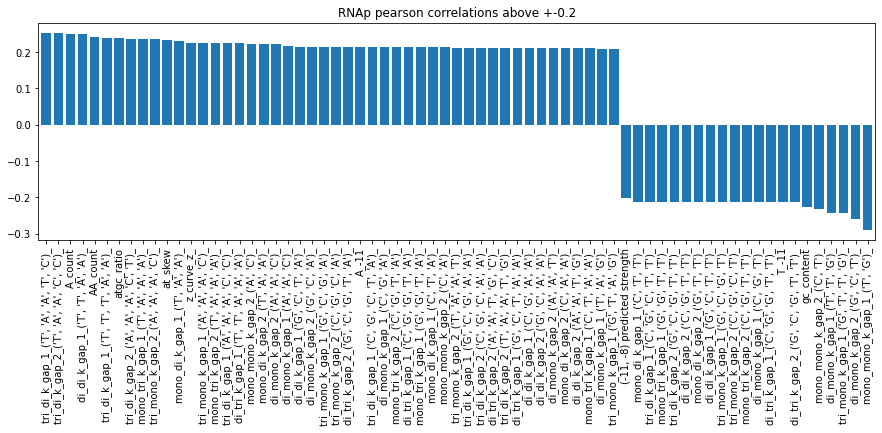

In [ ]:
RNAp_pearson_df=RNAp_pearson_df.sort_values(ascending=False)
RNAp_pearson_df.plot.bar( width=0.8,figsize=(15,4),title='RNAp pearson correlations above +-0.2')


<Axes: title={'center': 'RNAi pearson correlations above +-0.3'}>

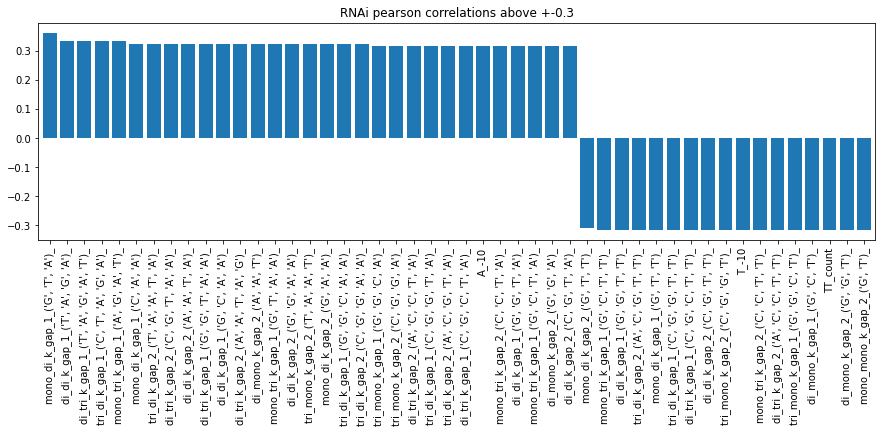

In [ ]:
RNAi_pearson_df=RNAi_pearson_df.sort_values(ascending=False)
RNAi_pearson_df.plot.bar( width=0.8,figsize=(15,4),title='RNAi pearson correlations above +-0.3')

## Models

### Data preperation

In [69]:
# train-test split

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(RNAi_X, RNAi_y, test_size=0.15,stratify=RNAi_X['Hight_or_low'])

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(RNAp_X, RNAp_y, test_size=0.15,stratify=RNAp_X['Hight_or_low'])


In [ ]:
numeric_features_i = X_train_i.select_dtypes(include='float64', exclude='int64')
numeric_features_p = X_train_p.select_dtypes(include='float64', exclude='int64')

scaler = StandardScaler()

scaler_i = scaler.fit(X_train_i.loc[:,numeric_features_i.columns])
X_train_i.loc[:, numeric_features_i.columns] = scaler_i.transform(X_train_i.loc[:, numeric_features_i.columns])
X_test_i.loc[:, numeric_features_i.columns] = scaler_i.transform(X_test_i.loc[:, numeric_features_i.columns])

scaler_p = scaler.fit(X_train_p.loc[:,numeric_features_p.columns])
X_train_p.loc[:, numeric_features_p.columns] = scaler_p.transform(X_train_p.loc[:, numeric_features_p.columns])
X_test_p.loc[:, numeric_features_p.columns] = scaler_p.transform(X_test_p.loc[:, numeric_features_p.columns])

In [ ]:
X_train_i.loc[:, numeric_features_i.columns]

,Predicted Promoter Strength,gc_content,gc_skew,at_skew,atgc_ratio,"(-33, -30) predicted strength","(-10, -7) predicted strength","(-35, -1) predicted strength"
130,2.373733,-0.417995,-0.804375,-0.805194,0.356400,-0.704440,-0.091292,-0.658106
203,1.114349,-0.417995,-0.804375,-0.805194,0.356400,-0.704440,0.236750,-0.485724
198,-0.204544,1.566684,-0.894932,-0.859473,-1.459121,-0.827215,-0.091292,-0.764444
138,-0.282906,-0.417995,-0.804375,-1.836505,0.356400,1.384544,0.836115,1.638555
276,0.271502,-0.417995,-0.804375,0.226117,0.356400,0.631791,1.164157,1.158958
...,...,...,...,...,...,...,...,...
103,-0.356671,-0.417995,-0.804375,1.257428,0.356400,0.372099,-0.309385,0.159706
31,0.803078,0.574345,-1.574113,-2.455291,-0.608096,0.048313,0.836115,0.481212
41,2.616869,0.574345,-1.574113,-2.455291,-0.608096,-0.704440,0.836115,-0.170766
23,-1.768040,0.574345,-0.130853,-0.289538,-0.608096,0.768708,0.236750,0.790206


In [ ]:
X_train_p.loc[:, numeric_features_p.columns]

,Predicted Promoter Strength (KbT),gc_content,gc_skew,at_skew,atgc_ratio,"(-33, -30) predicted strength","(-11, -8) predicted strength","(-35, -1) predicted strength"
756,-0.179972,-0.377995,-1.630429,0.890189,0.292628,0.149454,-1.015220,-0.569564
707,1.134457,1.076463,0.147308,-1.288724,-1.044467,0.149454,-0.275324,-0.071187
723,-1.944319,-1.105224,0.528252,0.712662,1.104436,1.557185,0.558373,1.566654
97,1.315090,1.076463,-1.185995,-3.015411,-1.044467,0.423042,1.674750,1.451510
825,-0.581899,-0.377995,1.391724,0.890189,0.292628,-0.431813,-0.037329,-0.355287
...,...,...,...,...,...,...,...,...
197,0.079314,-1.105224,0.528252,-0.032952,1.104436,-0.917167,1.536264,0.333572
550,0.616550,-0.377995,-0.119353,-0.672051,0.292628,-1.839544,0.696859,-0.937036
99,-0.007337,-0.377995,-1.630429,-0.672051,0.292628,0.149454,0.320379,0.330064
502,-0.445924,-1.832453,-0.468063,1.263768,2.041138,0.764153,0.558373,0.960341


### Lasso

In [ ]:
# RNA i
# define the model
lasso_model_i = Lasso(alpha=0.3, max_iter=5000)
# training the model
_ = lasso_model_i.fit(X_train_i, y_train_i)
# Predict
y_pred_i = lasso_model_i.predict(X_test_i)

# RNA p
# define the model
lasso_model_p = Lasso(alpha=0.3, max_iter=5000)
# training the model
_ = lasso_model_p.fit(X_train_p, y_train_p)
# Predict
y_pred_p = lasso_model_p.predict(X_test_p)

In [ ]:
# evaluation
r2_score_p = r2_score(y_test_p, y_pred_p)
print('the R2 score for priming RNA is %.5f' % r2_score_p)
r2_score_i = r2_score(y_test_i, y_pred_i)
print('the R2 score for inhibitor RNA is %.5f' % r2_score_i)

the R2 score for priming RNA is 0.02001
the R2 score for inhibitor RNA is 0.24480


number of non-zero coefficients is: 60


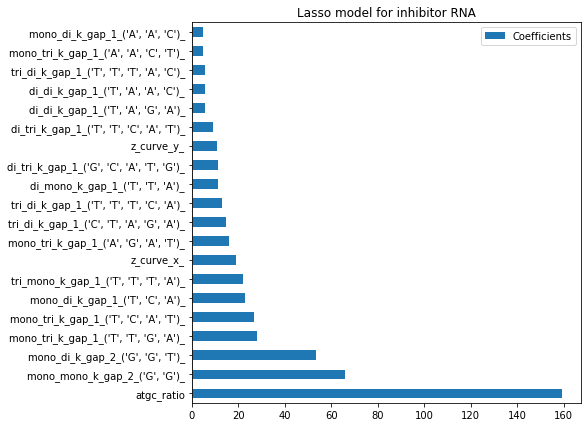

In [ ]:
# Features importance RNA i
importance = lasso_model_i.coef_
features = X_train_i.columns[importance!=0]
importance = importance[importance!=0]
print(f'number of non-zero coefficients is: {len(features)}')

# plot best 20 features
idx = (-importance).argsort()[:20]
coefs = pd.DataFrame(
   importance[idx],
   columns=['Coefficients'], index=features[idx]
)

coefs.plot(kind='barh', figsize=(9, 7))
plt.title('Lasso model for inhibitor RNA')
plt.axvline(x=0, color='.5')
plt.subplots_adjust(left=.3)

number of non-zero coefficients is: 88


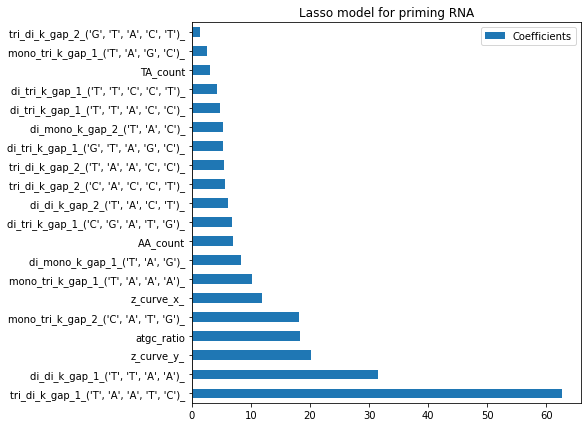

In [ ]:
# Features importance RNA p
importance = lasso_model_p.coef_
features = X_train_p.columns[importance!=0]
importance = importance[importance!=0]
print(f'number of non-zero coefficients is: {len(features)}')

# plot best 20 features
idx = (-importance).argsort()[:20]
coefs = pd.DataFrame(
   importance[idx],
   columns=['Coefficients'], index=features[idx]
)

coefs.plot(kind='barh', figsize=(9, 7))
plt.title('Lasso model for priming RNA')
plt.axvline(x=0, color='.5')
plt.subplots_adjust(left=.3)

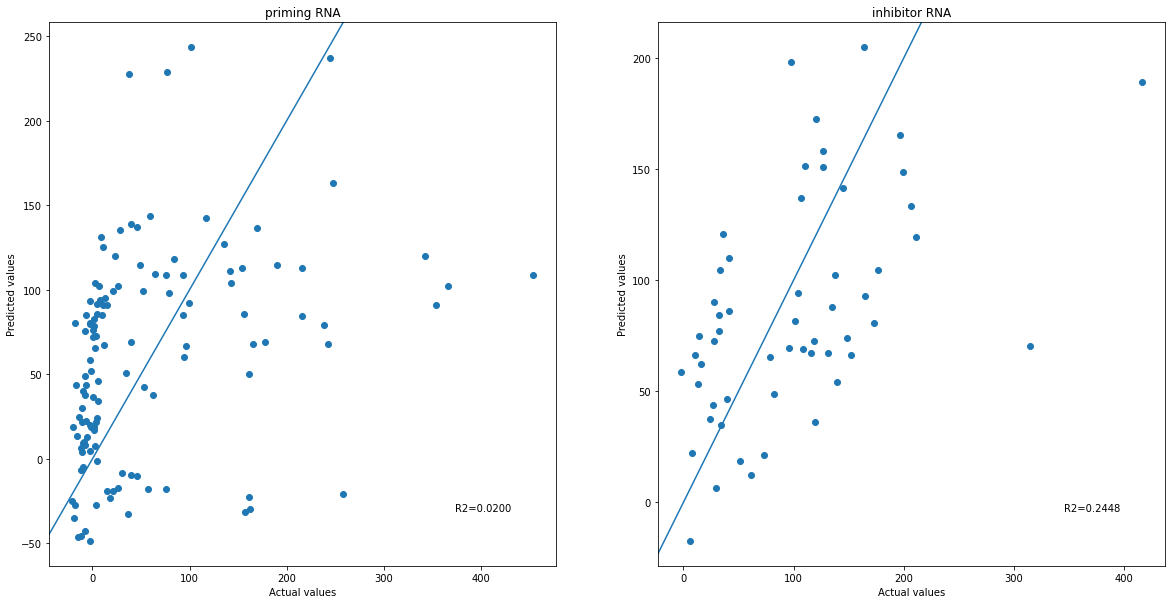

In [ ]:
# evaluation plots
fig, ax = plt.subplots(1,2, figsize=(20,10))
lst = [[y_test_p, y_pred_p], [y_test_i, y_pred_i]]
r2_lst = [r2_score_p, r2_score_i]
for i in range(len(lst)):
  _ = ax[i].scatter(lst[i][0], lst[i][1])
  _ = ax[i].axline((0, 0), slope=1)
  _ = ax[i].set_xlabel('Actual values')
  _ = ax[i].set_ylabel('Predicted values')
  _ = ax[i].text(0.8, 0.1, 'R2=%.4f' %r2_lst[i], transform = ax[i].transAxes) 
_ = ax[0].set_title('priming RNA')
_ = ax[1].set_title('inhibitor RNA')

### Hyperparameter-tuning


In [ ]:
#random search
from  sklearn import metrics 
from sklearn.metrics  import fbeta_score, make_scorer
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
xgb_tuned = XGBRegressor(random_state=1)

parameters = {
    "n_estimators": [700,800],
    "subsample":[0.8],
    "learning_rate":[0.01],
    "gamma":[0.01],
    "colsample_bytree":[0.8],
    "alpha":[0.1],
    "max_depth":[5,7,9,11,12]
}
scorer = metrics.make_scorer(metrics.r2_score)

rand_obj = RandomizedSearchCV(xgb_tuned, parameters, scoring=scorer,n_iter=5, n_jobs=-1, cv=2, verbose=1)

rand_obj = rand_obj.fit(X_train_p, y_train_p)
print("Best parameters:", rand_obj.best_params_)
best_model = rand_obj.best_estimator_
y_pred_p = best_model.predict(X_test_p)
score = metrics.r2_score(y_test_p, y_pred_p)
print("R^2 score on test data:", score)

NameError: ignored

In [ ]:
pip install scikit-optimize

In [ ]:
#bayesian search
from skopt import BayesSearchCV
bayes = BayesSearchCV(XGBRegressor(random_state=1),search_spaces=parameters, n_iter=20, cv=5)
bayes.fit(X_train_p, y_train_p)
print("Best parameters:", bayes.best_params_)
print("Lowest RMSE: ", (-bayes.best_score_)**(1/2.0))

In [ ]:
#continues bayesSearch
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from sklearn.model_selection import cross_val_score
from skopt import gp_minimize

bayes_space = XGBRegressor()

space  = [Integer(1, 20, name='max_depth'),
          Real(10**-5, 10**0, "log-uniform", name='learning_rate'),
          Real(0.5, 1,"uniform", name='subsample'),
          Real(10**-5, 10**1, "uniform", name='gamma'),
          Real(10**-5, 10**0, "uniform", name='alpha'),]

# The decorator below enables the objective function
# to receive the parameters as keyword arguments.
@use_named_args(space)
def objective(**params):
    '''
    Scitkit Learn Optimize requires an objective function to minimize.
    We use the average of cross-validation mean absolute errors as 
    the objective function (also called cost function in optimization)
    '''
    xgb.set_params(**params)

    return -np.mean(cross_val_score(xgb, X_train_p, y_train_p, cv=5, n_jobs=-1,
                                    scoring="neg_mean_absolute_error"))




res_gp = gp_minimize(objective, space, n_calls=20, random_state=0)

## XGBoost

In [ ]:
from xgboost import XGBRegressor
# RNA p
xgb_model_p = XGBRegressor()
xgb_model_p.fit(X_train_p, y_train_p) 
y_pred_p = xgb_model_p.predict(X_test_p)
# RNA i
xgb_model_i = XGBRegressor()
xgb_model_i.fit(X_train_i, y_train_i)
y_pred_i = xgb_model_i.predict(X_test_i)

In [ ]:
# evaluation
r2_score_p = r2_score(y_test_p, y_pred_p)
print('the R2 score of priming RNA is %.5f' % r2_score_p)
r2_score_i = r2_score(y_test_i, y_pred_i)
print('the R2 score of inhibitor RNA is %.5f' % r2_score_i)

the R2 score of priming RNA is 0.86468
the R2 score of inhibitor RNA is 0.43171


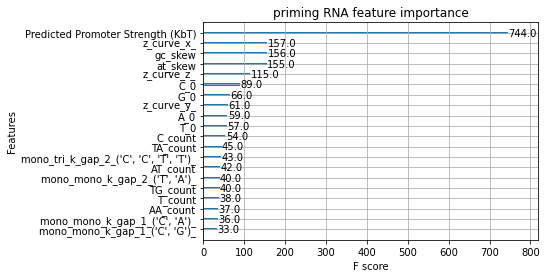

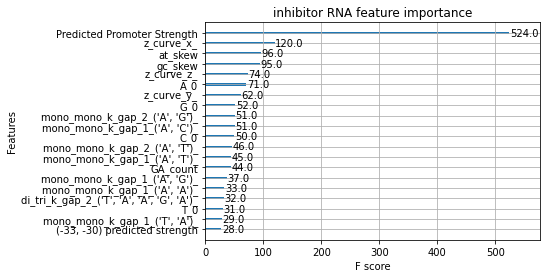

In [ ]:
# plot feature importance
from xgboost import plot_importance
plot_importance(xgb_model_p, max_num_features= 20, title = 'priming RNA feature importance')
plt.show()
plot_importance(xgb_model_i, max_num_features= 20, title = 'inhibitor RNA feature importance')
plt.show()

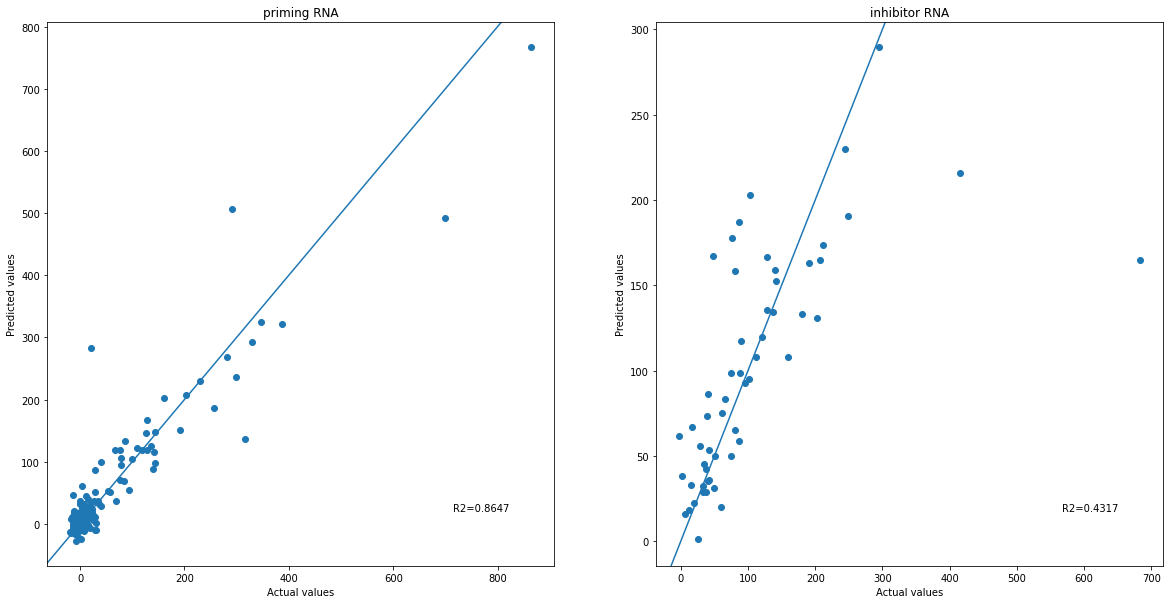

In [ ]:
# evaluation plots
fig, ax = plt.subplots(1,2, figsize=(20,10))
lst = [[y_test_p, y_pred_p], [y_test_i, y_pred_i]]
r2_lst = [r2_score_p, r2_score_i]
for i in range(len(lst)):
  _ = ax[i].scatter(lst[i][0], lst[i][1])
  _ = ax[i].axline((0, 0), slope=1)
  _ = ax[i].set_xlabel('Actual values')
  _ = ax[i].set_ylabel('Predicted values')
  _ = ax[i].text(0.8, 0.1, 'R2=%.4f' %r2_lst[i], transform = ax[i].transAxes) 

_ = ax[0].set_title('priming RNA')
_ = ax[1].set_title('inhibitor RNA')

## Shared Model

In [ ]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(X_shared_model, Y_shared_model, test_size=0.2)

#scaling
numeric_features = X_train.select_dtypes(include='float64', exclude='int64')

scaler = StandardScaler()

scaler = scaler.fit(X_train.loc[:,numeric_features.columns])
X_train.loc[:, numeric_features.columns] = scaler.transform(X_train.loc[:, numeric_features.columns])
X_test.loc[:, numeric_features.columns] = scaler.transform(X_test.loc[:, numeric_features.columns])

#model
from xgboost import XGBRegressor
xgb_model = XGBRegressor()
xgb_model.fit(X_train, y_train) 
y_pred = xgb_model.predict(X_test)

# evaluation
r2_score = r2_score(y_test, y_pred)
print('the R2 score of the shared model is %.5f' % r2_score)

the R2 score of the shared model is 0.78619


In [ ]:
# # evaluation plots
# fig, ax = plt.subplots(1,2, figsize=(20,10))
# lst = [[y_test_p, y_pred_p], [y_test_i, y_pred_i]]
# r2_lst = [r2_score_p, r2_score_i]
# for i in range(len(lst)):
#   _ = ax[i].scatter(lst[i][0], lst[i][1])
#   _ = ax[i].axline((0, 0), slope=1)
#   _ = ax[i].set_xlabel('Actual values')
#   _ = ax[i].set_ylabel('Predicted values')
#   _ = ax[i].text(0.8, 0.1, 'R2=%.4f' %r2_lst[i], transform = ax[i].transAxes) 

# _ = ax[0].set_title('priming RNA')
# _ = ax[1].set_title('inhibitor RNA')